In [1]:
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Reshape
from keras.utils import to_categorical
from keras.optimizers import Adam

In [2]:
# Chargement du dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalisation des images entre 0 et 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
# Redimensionner les donnees pour qu'elles aient une forme de (28*28,)
x_train = x_train.reshape((-1, 28*28))
x_test = x_test.reshape((-1, 28*28))

In [5]:
# Convertir les etiquettes en format one-hot encoding <=> ex pour 3 => [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
# Taille de l'espace latent
latent_dim = 64

In [7]:
# Definition de l'encodeur
inputs = Input(shape=(28*28,))  # Image d'entree de taille 28*28
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
latent = Dense(latent_dim, activation='relu')(x)  # Espace latent

In [8]:
# Definition du decodeur
x = Dense(64, activation='relu')(latent)
x = Dense(128, activation='relu')(x)
decoded = Dense(28*28, activation='sigmoid')(x)  # Image reconstruite (sortie)

In [9]:
# Couche de classification
classification = Dense(10, activation='softmax')(latent)  # Prediction de la classe

In [10]:
# Modele final
autoencoder = Model(inputs, [decoded, classification])

In [29]:
# Compilation du modele

autoencoder.compile(optimizer=Adam(), loss=['binary_crossentropy', 'categorical_crossentropy'], metrics=['mse','accuracy'])


In [30]:
# Entrainement du modele
autoencoder.fit(x_train, [x_train, y_train], epochs=10, batch_size=128, validation_data=(x_test, [x_test, y_test]))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - dense_5_loss: 0.0984 - dense_5_mse: 0.0120 - dense_6_accuracy: 0.9970 - dense_6_loss: 0.0086 - loss: 0.1070 - val_dense_5_loss: 0.0975 - val_dense_5_mse: 0.0118 - val_dense_6_accuracy: 0.9749 - val_dense_6_loss: 0.1375 - val_loss: 0.2366
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - dense_5_loss: 0.0978 - dense_5_mse: 0.0118 - dense_6_accuracy: 0.9967 - dense_6_loss: 0.0101 - loss: 0.1079 - val_dense_5_loss: 0.0965 - val_dense_5_mse: 0.0115 - val_dense_6_accuracy: 0.9785 - val_dense_6_loss: 0.1246 - val_loss: 0.2226
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - dense_5_loss: 0.0981 - dense_5_mse: 0.0119 - dense_6_accuracy: 0.9960 - dense_6_loss: 0.0124 - loss: 0.1105 - val_dense_5_loss: 0.0973 - val_dense_5_mse: 0.0117 - val_dense_6_accuracy: 0.9773 - val_dense_6_loss: 0.1377 - val_loss: 0.2367
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - dense_5_loss: 0.0969 - dense_5_mse: 0.0115 - dense_6_accuracy: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - dense_5_loss: 0.0957 - dense_5_mse: 0.0115 - dense_6_accuracy: 0.9734 - dense_6_loss: 0.1902 - loss: 0.2859
Perte totale : 0.2434
Perte reconstruction : 0.0956
Perte classification : 0.1475
Precision reconstruction : 0.0111
Precision classification : 0.9775
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


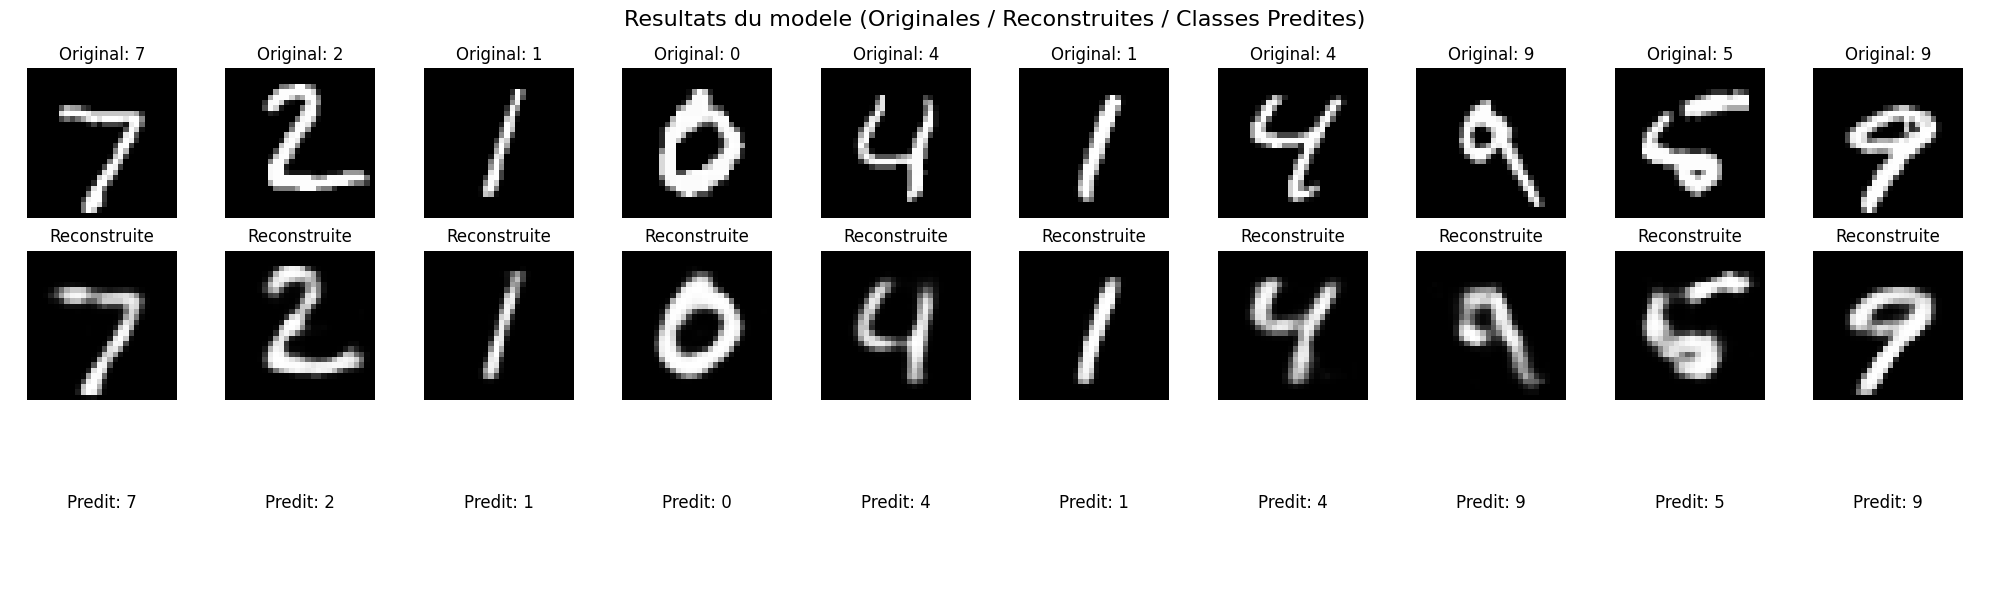

In [31]:
# Evaluation
loss, reconstruction_loss, classification_loss, reconstruction_acc, classification_acc = autoencoder.evaluate(x_test, [x_test, y_test])
print(f"Perte totale : {loss:.4f}")
print(f"Perte reconstruction : {reconstruction_loss:.4f}")
print(f"Perte classification : {classification_loss:.4f}")
print(f"Precision reconstruction : {reconstruction_acc:.4f}")
print(f"Precision classification : {classification_acc:.4f}")

# Faire des predictions
decoded_imgs, predicted_classes = autoencoder.predict(x_test)

# Convertir les predictions en labels (argmax)
y_pred_labels = np.argmax(predicted_classes, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Afficher les resultats pour 10 images
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Image originale
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Original: {y_true_labels[i]}")
    plt.axis('off')

    # Image reconstruite
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstruite")
    plt.axis('off')

    # Prediction de la classe
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.text(0.5, 0.5, f"Predit: {y_pred_labels[i]}", fontsize=12, ha='center')
    plt.axis('off')

plt.suptitle("Resultats du modele (Originales / Reconstruites / Classes Predites)", fontsize=16)
plt.tight_layout()
plt.show()
